In [33]:
import pandas as pd

In [34]:
df = pd.read_csv("shopping_dataset.csv")

In [35]:
df.head()

,age,monthly_income,daily_internet_hours,smartphone_usage_years,social_media_hours,online_payment_trust_score,tech_savvy_score,monthly_online_orders,monthly_store_visits,avg_online_spend,...,free_return_importance,product_availability_online,impulse_buying_score,need_touch_feel_score,brand_loyalty_score,environmental_awareness,time_pressure_level,gender,city_tier,shopping_preference
0,56,221111,6.5,12,0.7,1,6,16,16,28551,...,7,7,1,3,6,5,2,Other,Tier 3,Store
1,69,96029,8.2,13,2.7,6,9,14,1,124056,...,3,4,9,6,8,1,7,Male,Tier 3,Hybrid
2,46,19055,6.4,4,2.1,10,8,2,0,81939,...,4,10,1,1,3,3,3,Female,Tier 3,Store
3,32,53170,6.4,11,0.7,2,10,20,3,35901,...,10,2,4,8,2,6,6,Female,Tier 1,Store
4,60,244016,6.0,5,0.7,2,5,18,16,131971,...,2,5,8,9,7,1,6,Male,Tier 3,Store


In [36]:
print(f"{len(df.columns)} columns in total")

25 columns in total


In [37]:
for column in df.columns:
    print(column)
    print(df[column].nunique())

age
62
monthly_income
11504
daily_internet_hours
111
smartphone_usage_years
14
social_media_hours
61
online_payment_trust_score
10
tech_savvy_score
10
monthly_online_orders
50
monthly_store_visits
20
avg_online_spend
11347
avg_store_spend
11324
discount_sensitivity
10
return_frequency
10
avg_delivery_days
7
delivery_fee_sensitivity
10
free_return_importance
10
product_availability_online
10
impulse_buying_score
10
need_touch_feel_score
10
brand_loyalty_score
10
environmental_awareness
10
time_pressure_level
10
gender
3
city_tier
3
shopping_preference
3


In [38]:
# Let us explore the columns with less than 10 unique contents
for column in df.columns:
    if df[column].nunique() < 11:
        print(column)
        print(df[column].unique())

online_payment_trust_score
[ 1  6 10  2  4  5  8  7  9  3]
tech_savvy_score
[ 6  9  8 10  5  7  3  1  4  2]
discount_sensitivity
[ 2  4  9  7  5 10  8  3  6  1]
return_frequency
[3 7 4 0 9 8 5 1 6 2]
avg_delivery_days
[2 4 5 3 7 6 1]
delivery_fee_sensitivity
[ 6  1  3  4  5 10  2  9  7  8]
free_return_importance
[ 7  3  4 10  2  9  6  1  5  8]
product_availability_online
[ 7  4 10  2  5  6  8  9  3  1]
impulse_buying_score
[ 1  9  4  8  6 10  5  7  2  3]
need_touch_feel_score
[ 3  6  1  8  9  4  2 10  7  5]
brand_loyalty_score
[ 6  8  3  2  7  4  9  5  1 10]
environmental_awareness
[ 5  1  3  6  4  9 10  2  7  8]
time_pressure_level
[ 2  7  3  6  8  4  5  1 10  9]
gender
['Other' 'Male' 'Female']
city_tier
['Tier 3' 'Tier 1' 'Tier 2']
shopping_preference
['Store' 'Hybrid' 'Online']


In [39]:
df['gender'].value_counts()

gender
Male      3966
Female    3931
Other     3892
Name: count, dtype: int64

We see most scores are from a scale of 1-10 

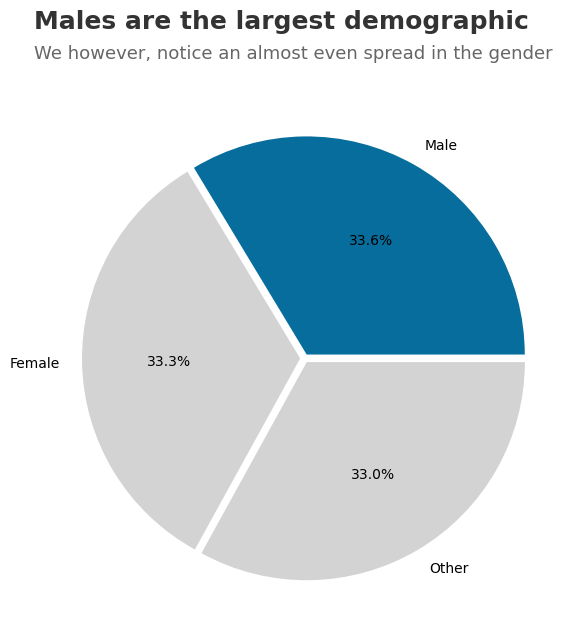

In [40]:
# curious about gender 

import matplotlib.pyplot as plt
import numpy as np
gender = df['gender'].value_counts()

fig, ax = plt.subplots(figsize=(6,6))

#setting the colors 
colors = ['#076D9C' if label == 'Male' else '#D3D3D3' for label in gender.index]

fig.text(0.07, 1.05, 'Males are the largest demographic', fontsize=18, fontweight='bold',color='#333333')
fig.text(0.07, 1.0, 'We however, notice an almost even spread in the gender', fontsize=13, color='#666666' )

# defining the size and names
data = gender.values
names = gender.index

# creating spacing between the slices 
spacing = [0.02] * len(gender)

# Percentage format of each slice 
percentage_format = '%1.1f%%'

# putting it all together 
wedges, texts, autotext = ax.pie(
    data, 
    labels=names,
    autopct=percentage_format,
    colors=colors,
    explode=spacing
)
plt.tight_layout()
plt.show()

In [41]:
df.columns

Index(['age', 'monthly_income', 'daily_internet_hours',
       'smartphone_usage_years', 'social_media_hours',
       'online_payment_trust_score', 'tech_savvy_score',
       'monthly_online_orders', 'monthly_store_visits', 'avg_online_spend',
       'avg_store_spend', 'discount_sensitivity', 'return_frequency',
       'avg_delivery_days', 'delivery_fee_sensitivity',
       'free_return_importance', 'product_availability_online',
       'impulse_buying_score', 'need_touch_feel_score', 'brand_loyalty_score',
       'environmental_awareness', 'time_pressure_level', 'gender', 'city_tier',
       'shopping_preference'],
      dtype='object')

In [43]:
df['age'].unique()

array([56, 69, 46, 32, 60, 25, 78, 38, 75, 36, 40, 28, 41, 70, 53, 57, 20,
       39, 19, 61, 47, 55, 77, 50, 29, 42, 66, 44, 76, 59, 45, 33, 79, 64,
       68, 72, 74, 54, 24, 26, 35, 21, 31, 67, 43, 37, 52, 34, 23, 71, 51,
       27, 48, 65, 62, 58, 18, 22, 30, 49, 73, 63])

In [45]:
bins = [0, 18, 25, 35, 45, 55, 65, 75, 100]
labels = ['0-17','18-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75+']

# creating age_group column
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# viewing the distribution
df['age_group'].value_counts()

age_group
35-44    1947
65-74    1922
45-54    1894
25-34    1877
55-64    1872
18-24    1287
75+       990
0-17        0
Name: count, dtype: int64

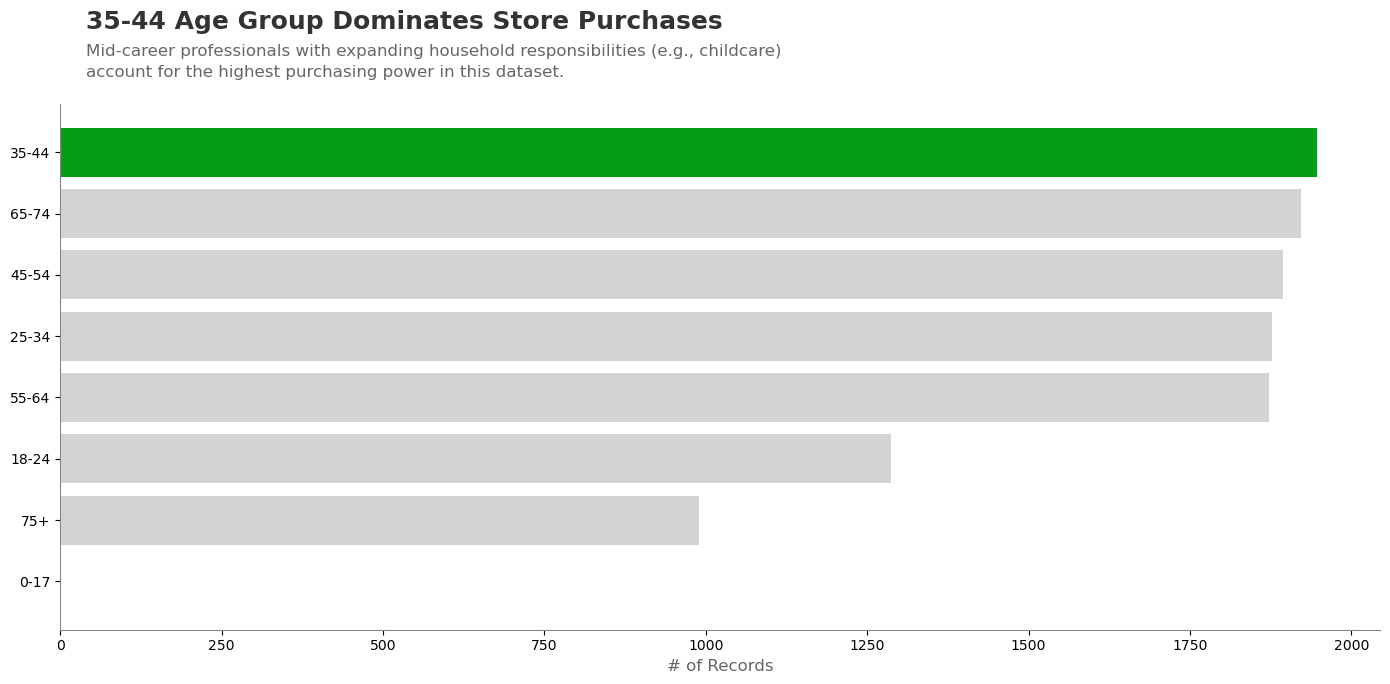

In [67]:
# Analyzing the ages of the users
age = df['age_group'].value_counts()

# setting the canvas
fig, ax = plt.subplots(figsize=(14,6))

# giving the largest age group color
colors = ['#079C16' if label == '35-44' else '#D3D3D3' for label in age.index[::-1]]
ax.barh(age.index[::-1], age.values[::-1], color=colors)

# Remove the top and right boarders 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Making the axis Margins more visible
ax.spines['bottom'].set_color('#888888')
ax.spines['left'].set_color('#888888')

# label the y-axis 
ax.set_xlabel('# of Records', color='#666666', fontsize=12)

# labels
# The Title: Bold and clear
fig.text(0.065, 1.10, "35-44 Age Group Dominates Store Purchases", 
         fontsize=18, fontweight='bold', color='#333333', ha='left')

# The Subnote: Insightful and concise
fig.text(0.065, 1.02, 
         "Mid-career professionals with expanding household responsibilities (e.g., childcare) \n"
         "account for the highest purchasing power in this dataset.", 
         fontsize=12, color='#666666', ha='left', linespacing=1.5)

# 
plt.tight_layout()
plt.show()